In [1]:
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
titanic = sns.load_dataset('titanic')

In [2]:
# 2) Pick a small, sensible set of columns
df = titanic[['survived', 'age', 'fare', 'sibsp', 'parch', 'sex', 'class', 'embarked']].copy()

# 3) Handle missing values
# numeric -> median, categorical -> most frequent
for col in ['age', 'fare']:
    df[col] = df[col].fillna(df[col].median())
for col in ['sex', 'class', 'embarked']:
    df[col] = df[col].fillna(df[col].mode()[0])

In [3]:
# 4) Label-encode the categoricals (simple & compact)
encoders = {}
for col in ['sex', 'class', 'embarked']:
    enc = LabelEncoder()
    df[col] = enc.fit_transform(df[col])
    encoders[col] = enc  # stored if you want to inspect mappings later

In [4]:
# 5) Split features/target and train/test
X = df.drop(columns='survived')
y = df['survived']

# we are doing this because we have to test the accuracy .. we don't need it if only prediction is asked.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [5]:
# Building the tree
from sklearn.tree import DecisionTreeClassifier as DT
from sklearn.metrics import accuracy_score as acc

# this is unpruned tree :
tree1 = DT(
    criterion="entropy"
)
tree1.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [6]:
# prediction of X-test is y_pred ... and we will compare this y_pred with y_test.
# y_pred will be encoded.
y_pred1 = tree1.predict(X_test)
print(y_pred1)
accuracy1 = acc(y_test, y_pred1)
print(accuracy1)

[0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 1 0 0 0 1 0 0 1 1 0 0 0 0 0
 0 0 0 0 1 0 1 0 0 0 0 0 1 0 1 1 0 0 1 0 0 0 1 0 0 1 0 1 1 0 1 0 0 0 0 0 0
 0 1 1 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 1 1 1 1 0 1 0 0 0 1 0 1 1 0 1 0 0
 0 0 1 1 0 1 1 1 0 1 0 0 0 1 0 1 0 0 1 0 0 1 0 1 1 0 0 0 1 0 0 1 1 0 1 0 0
 1 0 0 0 0 1 1 0 1 0 1 1 1 0 1 0 1 0 0 0 0 0 1 0 0 1 1 0 1 1 0]
0.7262569832402235


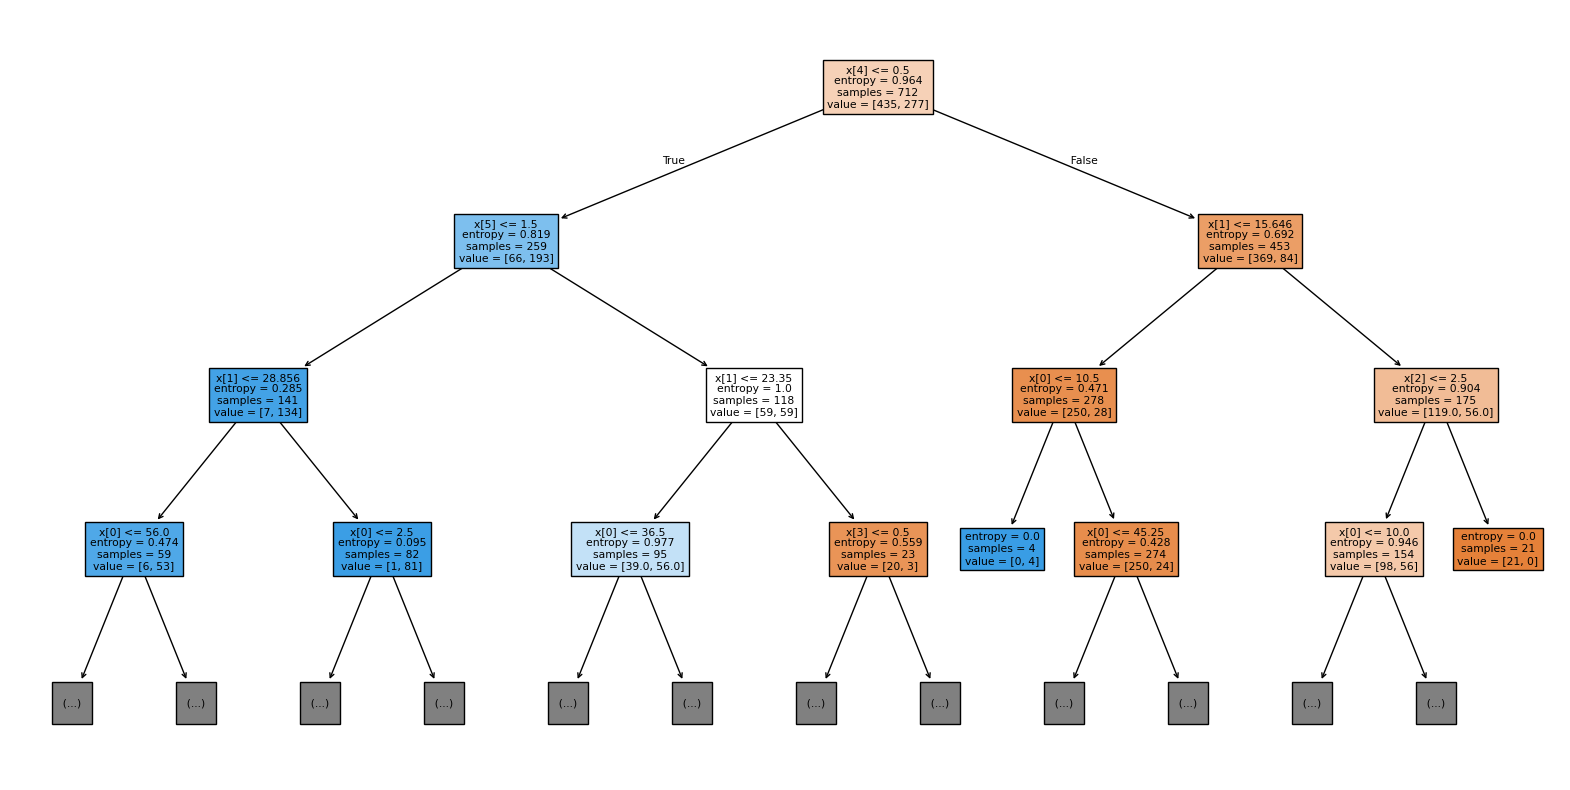

In [10]:
# C) VISUALIZE
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 10))
plot_tree(tree1, filled=True , max_depth = 3)
plt.show()